In [10]:
using Revise
using MajoranaPropagation
using PauliPropagation

using Plots 

Simulate the dynamics of the spinful Hubbard model on a 1D chain of $N$ spinful sites. The Hamiltonian is
$$\hat{H}=-t \sum_{i, \sigma=\{\uparrow, \downarrow\}}\left(\hat{c}_{i, \sigma}^{\dagger} \hat{c}_{i+1, \sigma}+\hat{c}_{i+1, \sigma}^{\dagger} \hat{c}_{i, \sigma}\right)+U \sum_i \hat{n}_{i \uparrow} \hat{n}_{i \downarrow}$$

In [11]:
N_spinful_sites = 20
t = 1.
U = 1.5

n_layers = 10
dt = 0.07

0.07

Get 1D connectivity, and create the circtuit for implementing a single layer of first order Trotterization.

In [12]:
topo = bricklayertopology(N_spinful_sites)

circ_single = []
thetas_single = []

#up hoppings 
for (i, j) in topo
    push!(circ_single, FermionicGate(:hopup, [i, j]))
    push!(thetas_single, -t * dt)
end

#down hoppings 
for (i, j) in topo
    push!(circ_single, FermionicGate(:hopdn, [i, j]))
    push!(thetas_single, -t * dt)
end

#on-site repulsion 
for i = 1:N_spinful_sites
    push!(circ_single, FermionicGate(:nupndn, i))
    push!(thetas_single, U * dt)
end

#### Set the truncations
1. `min_abs_coeff`: PP coefficient truncation
2. `max_unpaired`: number of unpaired Majoranas, namely the number of indices $i$ where only one of $\gamma_i$, $\gamma'_i$ are non-zero

In [13]:
min_abs_coeff = 1.e-8
max_unpaired = 10

10

Set the inital state as the checkerboard state $\ket{\uparrow\downarrow\cdots\uparrow\downarrow}$

In [14]:
#initial state 
initial_state_label = "Checkerboard"
fock_state = FockState(N_spinful_sites, :checkerboard, true)

fock_state

Fock state with 20 fermions at positions
    ↑: 1, 3, 5, 7, 9, 11, 13, 15, 17, 19
    ↓: 2, 4, 6, 8, 10, 12, 14, 16, 18, 20


Backpropagate $n_{2,\uparrow}$, the up density on site 2

In [15]:
# to = TimerOutput()

site_index = 3
obs = MajoranaSum(N_spinful_sites, :nup, site_index)

@show obs 

res = zeros(n_layers+1)
res[1] = overlapwithfock(obs, fock_state)

for k=1:n_layers
    propagate!(circ_single, obs, thetas_single, min_abs_coeff=min_abs_coeff, max_unpaired=max_unpaired)
    res[k+1] = overlapwithfock(obs, fock_state)
end 


obs = MajoranaSum with 2 terms:
    0.5 * 00000000000000000000000000000000000000000000000000000000000000000000000000000000
    0.5 * 00000000110000000000000000000000000000000000000000000000000000000000000000000000


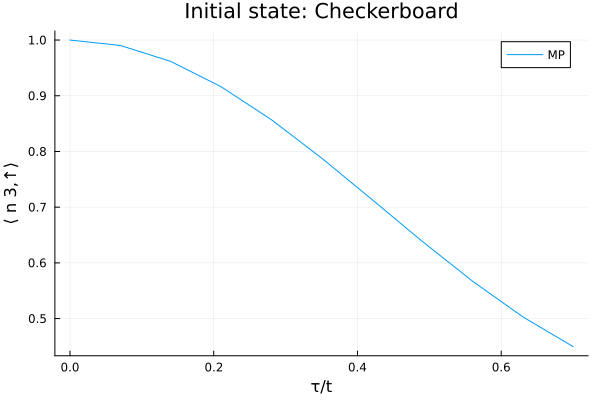

In [16]:
p = plot(dt*(0:n_layers)./ t, res, label="MP", xlabel="τ/t", ylabel="⟨ n $site_index,↑⟩", title = "Initial state: " * initial_state_label)

display(p)

Let's now consider the more complex observable $O = n_{2, \uparrow}n_{6,\downarrow}n_{10,\uparrow}$

In [17]:
min_abs_coeff = 1.e-5
max_unpaired = 8

site_index = 2
obs = MajoranaSum(N_spinful_sites, :nup, site_index) * MajoranaSum(N_spinful_sites, :ndn, site_index + 4) * MajoranaSum(N_spinful_sites, :nup, site_index + 8)

@show obs 

res = zeros(n_layers+1)
res[1] = overlapwithfock(obs, fock_state)

for k=1:n_layers
    propagate!(circ_single, obs, thetas_single, min_abs_coeff=min_abs_coeff, max_unpaired=max_unpaired)
    res[k+1] = overlapwithfock(obs, fock_state)
    @show k, length(obs)
end 

obs = MajoranaSum with 8 terms:
    0.125 * 00000000000000000000000000000000000000000000000000000000000000000000000000000000
    0.125 * 00000000000000000000000000000000000011000000000000000000000000000000000000000000
    0.125 * 00000000000000000000001100000000000000000000000000000000000000000000000000000000
    -0.125 * 00001100000000000000001100000000000011000000000000000000000000000000000000000000
    -0.125 * 00001100000000000000000000000000000011000000000000000000000000000000000000000000
    -0.125 * 00000000000000000000001100000000000011000000000000000000000000000000000000000000
    -0.125 * 00001100000000000000001100000000000000000000000000000000000000000000000000000000
    0.125 * 00001100000000000000000000000000000000000000000000000000000000000000000000000000
(k, length(obs)) = (1, 624)
(k, length(obs)) = (2, 2468)
(k, length(obs)) = (3, 6994)
(k, length(obs)) = (4, 13745)
(k, length(obs)) = (5, 28716)
(k, length(obs)) = (6, 53056)
(k, length(obs)) = (7, 94068)
(k, length(obs